In [2]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [8]:
dataset = make_blobs(centers=2)

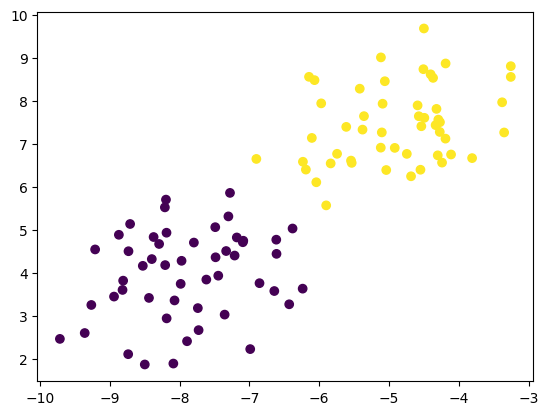

In [9]:
plt.scatter(dataset[0][:, 0], dataset[0][:, 1], c=dataset[1])

In [39]:
class ForestClassifier():
    def __init__(self, max_depth: int=5):
        self.max_depth = max_depth
        self.depth = 1;
        self.init = False;
    
    def gini_coefficient(self, x):
        diffsum = 0
        for i, xi in enumerate(x[:-1], 1):
            diffsum += np.sum(np.abs(xi - x[i:]))
        return diffsum / (len(x)**2 * np.mean(x) + 1)
    
    def fit(self, X, y):
        self.Xy = np.hstack((X, y.reshape(-1, 1)))

        if(self.depth >= self.max_depth): return

        for feat in range((X.shape[1])):
            X_new = self.Xy
            X_new = X_new[X_new[:, feat].argsort()]
            gini_vals = []
            for i in range(2, X_new.shape[0]): 
                gini_vals.append((
                    (self.gini_coefficient(X_new[:, 2][:i]) + self.gini_coefficient(X_new[:, 2][i:])) / 2
                ))

            gini_vals = np.array(gini_vals)
            print(gini_vals)
            if(len(gini_vals) == 0): return
            split_pos = np.argmin(gini_vals);

            self.depth += 1;

            self.fit(X[:split_pos], y[:split_pos])
            self.fit(X[split_pos + 1:], y[split_pos + 1:])
            
            self.depth -= 1;
            

In [40]:
model = ForestClassifier().fit(dataset[0], dataset[1])

[0.24484799 0.2422181  0.23953343 0.23679225 0.23399277 0.23113309
 0.22821126 0.22522523 0.22217285 0.2190519  0.21586003 0.21259481
 0.20925366 0.20583392 0.20233278 0.19874729 0.19507437 0.19131079
 0.18745314 0.18349785 0.17944117 0.17527915 0.17100763 0.16662223
 0.16211835 0.1574911  0.15273535 0.14784568 0.14281634 0.13764126
 0.13231403 0.12682781 0.1211754  0.11534912 0.10934083 0.10314186
 0.09674299 0.09013438 0.08330556 0.07624534 0.06894174 0.06138197
 0.54025501 0.53278609 0.52500221 0.51688799 0.50842667 0.4996
 0.49038808 0.48076923 0.47619048 0.46875    0.46082949 0.45289855
 0.44510386 0.4375     0.43010753 0.42293233 0.41597338 0.40922619
 0.40268456 0.39634146 0.39018952 0.38422131 0.37842952 0.37280702
 0.36734694 0.36204268 0.35688794 0.35187668 0.34700315 0.3422619
 0.33764772 0.33315565 0.32878098 0.32451923 0.32036613 0.31631763
 0.31236985 0.30851911 0.3047619  0.30109489 0.29751488 0.29401882
 0.29060381 0.28726708 0.28400598 0.28081797 0.27770064 0.27465166
